# Uso basico de XAI-metrics con configuracion YAML

Este notebook muestra el flujo minimo de evaluacion usando solamente `config_example.yaml`. El archivo de configuracion define donde estan los datos, el modelo, las atribuciones y las metricas que se van a ejecutar.

## 1. Preparar el entorno

El paquete debe estar instalado en modo editable con `pip install -e .`. La primera celda deja el notebook preparado para ejecutarse desde la raiz del proyecto o desde `examples/`, y registra en memoria los simbolos que necesita el modelo de ejemplo serializado.

In [15]:
import os
import sys
import types
from pathlib import Path

import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn
import yaml
from IPython.display import display
from lime.lime_tabular import LimeTabularExplainer

ROOT = Path.cwd()
if ROOT.name == "examples":
    PROJECT_ROOT = ROOT.parent
    EXAMPLES_DIR = ROOT
else:
    PROJECT_ROOT = ROOT
    EXAMPLES_DIR = ROOT / "examples"

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(EXAMPLES_DIR)

from xai_metrics.runner import run_evaluation


## 2. Revisar la configuracion

`config_example.yaml` usa rutas relativas a la carpeta `examples/`. Con esa configuracion, la evaluacion descubre automaticamente el dataset `hydraulic`, el modelo `IForest` y los metodos de atribucion disponibles en `results/attributions`.

In [16]:
CONFIG_PATH = Path("config_example.yaml")

with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

config

{'context': {'device': 'cpu',
  'datasets_dir': 'data',
  'models_dir': 'models',
  'attributions_dir': 'attributions'},
 'metrics': [{'name': 'Complexity', 'params': {'normalise': True}},
  {'name': 'Sparseness', 'params': {'normalise': True}},
  {'name': 'Faithfulness', 'params': {'base_strategy': 'mean'}},
  {'name': 'LocalLipschitzEstimate',
   'params': {'nr_samples': 200, 'normalise': True}}]}

## 3. Definir funciones de explicacion

`LocalLipschitzEstimate` necesita recalcular explicaciones sobre muestras perturbadas. El YAML decide que metodos y metricas se evaluan; estas funciones solo proporcionan a la metrica como regenerar atribuciones para cada metodo XAI.

In [17]:
X_reference = pd.read_csv("data/hydraulic/X_test.csv", index_col=0)


def _unwrap_detector(model, required_method):
    if hasattr(model, required_method):
        return model
    if hasattr(model, "model") and hasattr(model.model, required_method):
        return model.model
    raise AttributeError(f"No se encontro {required_method} en {type(model)} ni en model.model")


def _as_dataframe(inputs, columns):
    if isinstance(inputs, pd.DataFrame):
        return inputs.loc[:, columns]
    if isinstance(inputs, torch.Tensor):
        values = inputs.detach().cpu().numpy()
    else:
        values = np.asarray(inputs)
    if values.ndim == 1:
        values = values.reshape(1, -1)
    return pd.DataFrame(values, columns=columns)


def make_lime_explain_func(background):
    columns = list(background.columns)
    explainer = LimeTabularExplainer(
        background.to_numpy(),
        feature_names=columns,
        mode="classification",
        random_state=42,
    )

    def explain_func(model, inputs, targets=None, **kwargs):
        detector = _unwrap_detector(model, "predict_proba")
        X_batch = _as_dataframe(inputs, columns)
        attributions = []
        for row in X_batch.to_numpy():
            explanation = explainer.explain_instance(
                data_row=row,
                predict_fn=detector.predict_proba,
                num_features=len(columns),
            )
            weights = np.zeros(len(columns), dtype=float)
            for feature_idx, weight in explanation.as_map()[1]:
                weights[feature_idx] = float(weight)
            attributions.append(weights)
        return np.asarray(attributions)

    return explain_func


def make_shap_explain_func(background):
    columns = list(background.columns)

    def explain_func(model, inputs, targets=None, **kwargs):
        detector = _unwrap_detector(model, "decision_function")
        X_batch = _as_dataframe(inputs, columns)

        def score_function(values):
            values_df = pd.DataFrame(values, columns=columns)
            return detector.decision_function(values_df)

        explainer = shap.Explainer(score_function, background)
        shap_values = explainer(X_batch)
        return np.abs(shap_values.values)

    return explain_func


explain_funcs = {
    "LIME": make_lime_explain_func(X_reference),
    "SHAP": make_shap_explain_func(X_reference),
}

## 4. Ejecutar la evaluacion

La llamada a `run_evaluation` recibe el YAML y las funciones de explicacion requeridas por `LocalLipschitzEstimate`. El resto de la evaluacion se construye desde `config_example.yaml`.

En este ejemplo los archivos se escriben en `results/reports`, dentro de la carpeta `examples/`. Si no se quisiera guardar este reporte la campo `report_output_dir` tendría el valor `None`.

In [18]:
REPORTS_DIR = Path("results/reports")

evaluation = run_evaluation(
    config=CONFIG_PATH,
    report_output_dir=REPORTS_DIR,
    explain_funcs=explain_funcs,
)

evaluation


Running XAI evaluation
  Dataset    : hydraulic
  Model      : IForest
  XAI method : LIME

Running XAI evaluation
  Dataset    : hydraulic
  Model      : IForest
  XAI method : SHAP


{'contexts': [{'metadata': {'dataset_name': 'hydraulic',
    'model_name': 'IForest',
    'xai_method_name': 'LIME'},
   'results': {'Complexity': [np.float64(1.1651165484771915),
     np.float64(0.8615800693120479),
     np.float64(1.3783726321694083),
     np.float64(1.1369552015690296),
     np.float64(1.2074305673320815),
     np.float64(1.5088303119656892),
     np.float64(1.37403277330477),
     np.float64(1.1173721664047336)],
    'Sparseness': [np.float64(0.5498676385672403),
     np.float64(0.6828919859440418),
     np.float64(0.44706838433838075),
     np.float64(0.5800231893462668),
     np.float64(0.5622077455016828),
     np.float64(0.3803970424909388),
     np.float64(0.4515311546907894),
     np.float64(0.6058591016973194)],
    'Faithfulness': [-0.8789326403297706,
     0.8128502497106297,
     0.2815096993651802,
     -0.9336221831761761,
     -0.9281564047792809,
     -0.9244381354092057,
     -0.32405142713753027,
     -0.9561862806273054],
    'LocalLipschitzEstimat

## 5. Ver el reporte

Las filas son metricas y las columnas son metodos de atribucion. En este ejemplo se comparan las atribuciones `LIME` y `SHAP` del modelo `IForest`.

In [19]:
comparison = evaluation["reports"]["hydraulic"]["IForest"]
display(comparison)

,dataset_name,model_name,metric,metric_params,LIME,SHAP
0,hydraulic,IForest,Complexity,{'normalise': True},1.218711,1.498500
1,hydraulic,IForest,Faithfulness,{'base_strategy': 'mean'},-0.481378,0.407578
2,hydraulic,IForest,LocalLipschitzEstimate,"{'nr_samples': 200, 'normalise': True}",16.853677,9.680764
3,hydraulic,IForest,Sparseness,{'normalise': True},0.532481,0.385798


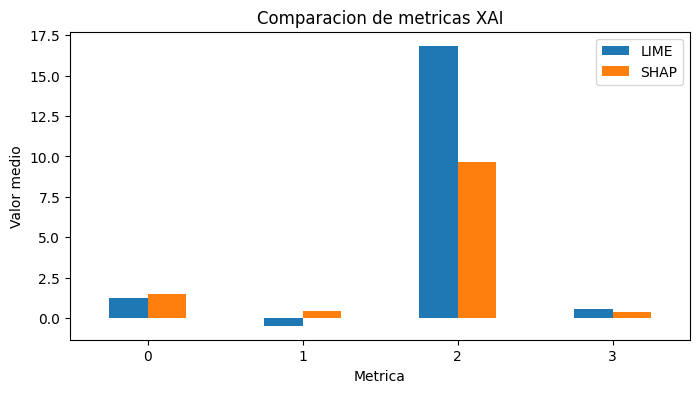

In [20]:
ax = comparison.plot.bar(figsize=(8, 4))
ax.set_title("Comparacion de metricas XAI")
ax.set_xlabel("Metrica")
ax.set_ylabel("Valor medio")
ax.tick_params(axis="x", rotation=0)